<a href="https://colab.research.google.com/github/Royromero/audiofiles_preply_transcript/blob/main/audio_transcript_preply.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rodrigo Romero Gregorio

In [4]:
"""

Main objetive is to gathering the audio files from the lesson recordings and transcribe them to text, then clean the text by removing accents and stopwords, and finally visualize the most common words in a bar plot.
After that, we will send the text to ChatGPT to summarize the text and generate a study guide for the lesson.

"""
import whisper
import os
import unicodedata
from nltk.corpus import stopwords
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import re
import numpy as np
import math


In [5]:
pip install openai.whisper

In [6]:
"""load the model from OpenAI to make the transcription of the audio file"""
model = whisper.load_model("tiny")

100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 211MiB/s]


In [7]:
def gathering_audio_files(dir_path):
    """
    Gather all audio files from the specified folder and return a list of their paths.
    """
    complete_text = []
    num_files = len(os.listdir(dir_path))
    for file in range(num_files):
         file= os.listdir(dir_path)[file]
         file_dir = os.path.join(dir_path, file)
         result = model.transcribe(file_dir)
         concatenated_text = result["text"]
         complete_text.append(concatenated_text)
         #print(f"File {file+1}/{num_files} processed: {file} characters: {len(concatenated_text)}")
    complete_text_str = "".join(complete_text)
    return complete_text_str

In [8]:
#Cargar google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
base_path = "/content/drive/MyDrive/preply_project"
#folders = os.listdir(base_path)
folders = ['lesson_recordings (1)', 'lesson_recordings (2)','lesson_recordings (3)','lesson_recordings (4)','lesson_recordings (5)']
data = {}
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        data[folder] = gathering_audio_files(folder_path)

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
/usr/local/lib/

In [11]:
"""We break down complete text in chunks"""

complete_text_str=data['lesson_recordings (1)']
# Example: Split text by sentences or line breaks
segments = complete_text_str.split('. ')
# Ensure you filter out empty strings
segments = [s.strip() for s in segments if s.strip()]

In [30]:
"""We tranform the text chunck into numerical chunks trough TF-IDF Term Frequency-Inverse Document Frequency"""
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text segments into numerical vectors
vectorizer = TfidfVectorizer(ngram_range=(1,2),stop_words='english')
X = vectorizer.fit_transform(segments)

In [31]:

"""Now we apply k-mean algorithm to clusterizing the chucks in two categories"""
from sklearn.cluster import KMeans

# Define the model for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

In [32]:
import pandas as pd

# Create a clean DataFrame to view the results
df = pd.DataFrame({
    'Speaker_Cluster': labels,
    'Text_Segment': segments
})

# Preview the results
print(df.head(20))

    Speaker_Cluster                                       Text_Segment
0                 0  you something important, talk to you something...
1                 0  Okay I'm not a I'm not a sporty person but for...
2                 0                              or refurbishing items
3                 0  The reason at first was because I wanted somet...
4                 0  And it would kind of help me sort through my t...
5                 0  You know? But eventually I noticed that while ...
6                 0  Everything can always be rewritten, everything...
7                 0   It doesn't mean that you have to start from zero
8                 0    It means you have to elevate from where you are
9                 0  And I think that really taught me something ve...
10                0  So do you see what I mean? It could be just ab...
11                0  You know? Like things that you thought that yo...
12                0  But then it's such a small, it's such a small ...
13    

In [33]:
df['Speaker_Cluster'][0]

np.int32(0)

In [34]:
# Ver 10 ejemplos asignados al Cluster 0
print("--- MUESTRA DEL CLUSTER 0 ---")
print(df[df['Speaker_Cluster'] == 0]['Text_Segment'].sample(min(10, len(df))).values)

print("\n--- MUESTRA DEL CLUSTER 1 ---")
# Ver 10 ejemplos asignados al Cluster 1
print(df[df['Speaker_Cluster'] == 1]['Text_Segment'].sample(min(10, len(df))).values)

--- MUESTRA DEL CLUSTER 0 ---
['I feel like you could improve number three, a little bit better'
 'My computer died' "Something's going on"
 "For example, in fact, in my last travel, I met the magic and culture that is a culture that is sophisticated in terms of math and us, I don't know how to say about it"
 "So I'll give you some time to do this part real quick"
 'We talked about new perspectives, what else? Is there other collocation that you used? Ah, great'
 'Okay'
 "It's just that somehow, somewhere in the middle, we get a little bit off track"
 'You know? But eventually I noticed that while trying to mend my mind from all my overthinking, that just like the item I am refurbishing, everything with a foundation can always start a new'
 'Okay, get ready']

--- MUESTRA DEL CLUSTER 1 ---
["You can see that there's a better word"
 "What's word is use or can be used"
 'That would support the word experience in this context'
 'The word is right there'
 'I wanted to give me at least one 

In [35]:
# Contar la distribución
print(df['Speaker_Cluster'].value_counts())

Speaker_Cluster
0    312
1     11
Name: count, dtype: int64


In [36]:
# Obtener las palabras del vectorizador
terms = vectorizer.get_feature_names_out()

# Ordenar los centroides de los clusters
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del Cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :50]] # Top 10 palabras
    print(", ".join(top_words))


📢 Palabras clave más importantes del Cluster 0:
okay, right, just, good, perfect, think, know, ready, let, yes, experience, vocabulary, maybe, travel, check, going, like, number, alright, really, say, okay okay, ll, try, don, bit, important, little, little bit, singular, new, example, answer, use, thursday, culture, speaking, actually, hmm, wonderful, help, look, kind, time, reason, right perfect, let know, quick, sentence, great

📢 Palabras clave más importantes del Cluster 1:
word, better, better word, experience, word experience, word right, look word, right, look, word use, use used, let, used, match experience, wanted word, word match, exposure work, work better, experience context, support, support word, called verb, verb word, word travels, verb, match, exposure, use, travels, dive, deep dive, let deep, dive word, context, called, deep, wanted, answer little, better time, try answer, work, bit better, let try, preparation ideas, trying tell, like better, better preparation, tel

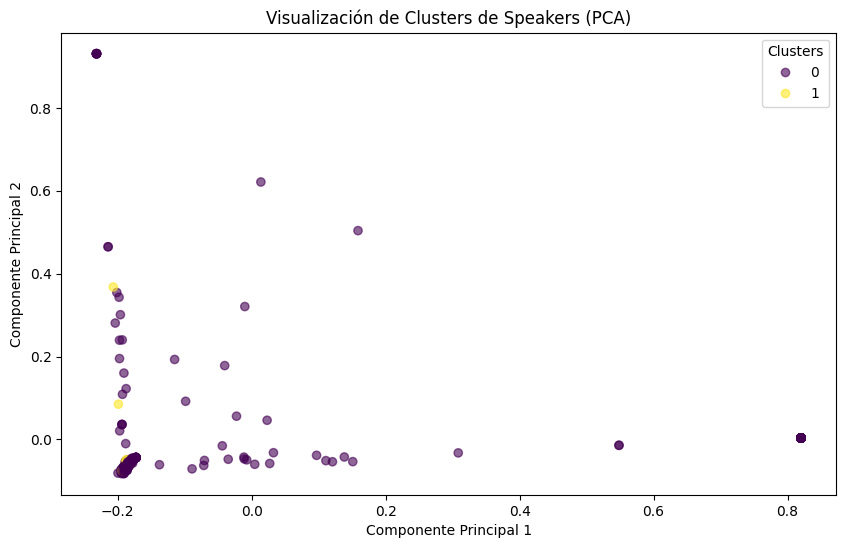

In [37]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir las dimensiones de la matriz TF-IDF a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_dense = X.todense()
coords = pca.fit_transform(np.asarray(X_dense))

# Graficar los puntos coloreados por su cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='viridis', alpha=0.6)

plt.title('Visualización de Clusters de Speakers (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del Cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))

In [38]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del Cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))


📢 Palabras clave más importantes del Cluster 0:
okay, right, just, good, perfect, think, know, ready, let, yes

📢 Palabras clave más importantes del Cluster 1:
word, better, better word, experience, word experience, word right, look word, right, look, word use
